NOTE: This is lecture is meant to be viewed as an .ipynb ( Python Jupyter Notebook esp. in Google Colab: https://drive.google.com/file/d/1Ohwhdr-wzrD_Idd1u4VDS8T4nd4QI4a2/view?usp=sharing )

Please, contact author Robin Yancey for .ipynb or use above link.

# Assessment Solutions

Worked solutions for the exercises in `ML_Pandas_NumPy_KNN_Assesment_and_Full_Lecture.ipynb`.

**Run the Setup cell below first** — it loads the data and recreates every variable the solutions use, so each solution can be run independently.


## Setup


In [ ]:
# === Setup: run this cell first ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
sns.set_theme(style="whitegrid")

DATA_DIR = "drive_data"

# Load and clean the primary dataset
df = pd.read_csv(os.path.join(DATA_DIR, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df_clean = df.dropna().reset_index(drop=True)
df_clean["gender_num"] = df_clean["gender"].map({"Male": 0, "Female": 1})
df_clean["ContractOrdinal"] = df_clean["Contract"].map(
    {"Month-to-month": 0, "One year": 1, "Two year": 2})
df_clean["ChargesPerMonth"] = df_clean["TotalCharges"] / df_clean["tenure"]

# Secondary datasets
vertebrae = pd.read_csv(os.path.join(DATA_DIR, "column_3C.dat"), sep=" ", header=None)
missed = pd.read_csv(os.path.join(DATA_DIR, "KaggleV2-May-2016.csv"))

# Regression data (predict TotalCharges from tenure + MonthlyCharges)
X = df_clean[["tenure", "MonthlyCharges"]]
y = df_clean["TotalCharges"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
_scaler = StandardScaler()
X_train_scaled = _scaler.fit_transform(X_train)
X_test_scaled = _scaler.transform(X_test)

# Classification data (predict Churn)
X_class = df_clean[["tenure", "MonthlyCharges", "TotalCharges"]]
y_class = LabelEncoder().fit_transform(df_clean["Churn"])
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class)
_sc = StandardScaler()
X_train_c = _sc.fit_transform(X_train_c)
X_test_c = _sc.transform(X_test_c)
X_class_scaled = StandardScaler().fit_transform(X_class)

print("Setup complete - all variables ready.")

Setup complete - all variables ready.


### ✅ Solution 1: NumPy arrays vs. Pandas structures

**Problem:** Create a NumPy array from the list `[3, 6, 9, 12, 15]` and print its mean and maximum. Then create a Pandas Series of the same values with index `['a','b','c','d','e']` and print the value stored at label `'d'`.


In [ ]:
values = [3, 6, 9, 12, 15]
arr = np.array(values)
print("mean:", arr.mean(), "| max:", arr.max())

s = pd.Series(values, index=["a", "b", "c", "d", "e"])
print("value at 'd':", s["d"])

mean: 9.0 | max: 15
value at 'd': 12


### ✅ Solution 2: Load a CSV and inspect it

**Problem:** Load the Telco CSV into a new variable `df_ex` using `pd.read_csv`, then print its shape and display the first 3 rows.


In [ ]:
df_ex = pd.read_csv(os.path.join(DATA_DIR, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))
print(df_ex.shape)
display(df_ex.head(3))

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### ✅ Solution 3: Quick structural summary

**Problem:** For `df_clean`, print (a) the number of rows, (b) the list of column names, and (c) how many of the columns are numeric.


In [ ]:
print("rows:", df_clean.shape[0])
print("columns:", df_clean.columns.tolist())
print("numeric columns:", len(df_clean.select_dtypes(include="number").columns))

rows: 7032
columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_num', 'ContractOrdinal', 'ChargesPerMonth']
numeric columns: 7


### ✅ Solution 4: Duplicates and uniqueness

**Problem:** Print the number of duplicate rows in `df_clean` and the number of unique values in the `PaymentMethod` column.


In [ ]:
print("duplicate rows:", df_clean.duplicated().sum())
print("unique PaymentMethod:", df_clean["PaymentMethod"].nunique())

duplicate rows: 0
unique PaymentMethod: 4


### ✅ Solution 5: Fill missing values instead of dropping

**Problem:** Instead of dropping rows with a missing `TotalCharges`, fill them with the column **median**. Start from a copy of the raw `df`, coerce `TotalCharges` to numeric, fill the `NaN`s with the median, and confirm 0 missing values remain.


In [ ]:
df_fill = df.copy()
df_fill["TotalCharges"] = pd.to_numeric(df_fill["TotalCharges"], errors="coerce")
median_val = df_fill["TotalCharges"].median()
df_fill["TotalCharges"] = df_fill["TotalCharges"].fillna(median_val)
print("median used:", median_val)
print("missing after fill:", df_fill["TotalCharges"].isna().sum())

median used: 1397.475
missing after fill: 0


### ✅ Solution 6: Separate the feature types

**Problem:** From `df_clean`, print the list of object (categorical) columns, and separately find the numeric column that has the **most** unique values.


In [ ]:
cats = df_clean.select_dtypes(include="object").columns.tolist()
num = df_clean.select_dtypes(include="number")
most_unique = num.nunique().idxmax()
print("categorical:", cats)
print("numeric col with most unique values:", most_unique,
      "(", num[most_unique].nunique(), "unique )")

categorical: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
numeric col with most unique values: ChargesPerMonth ( 6585 unique )


### ✅ Solution 7: Decide the task from the target

**Problem:** Using `df_clean`, decide whether predicting `gender` is a regression or classification task, and whether predicting `tenure` is. For each, print the column name, its dtype, its number of unique values, and the task type.


In [ ]:
for col in ["gender", "tenure"]:
    s = df_clean[col]
    task = "classification" if (s.dtype == "object" or s.nunique() <= 10) else "regression"
    print(f"{col}: dtype={s.dtype}, unique={s.nunique()} -> {task}")

gender: dtype=object, unique=2 -> classification
tenure: dtype=int64, unique=72 -> regression


### ✅ Solution 8: Histogram and correlation

**Problem:** Plot a histogram of `df_clean['MonthlyCharges']` and print its correlation with `TotalCharges`.


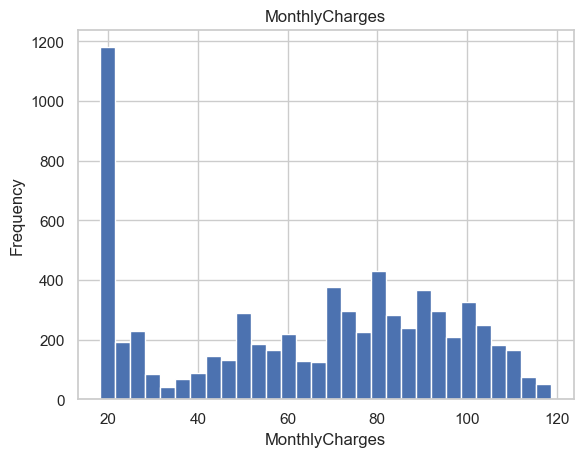

correlation: 0.651


In [ ]:
df_clean["MonthlyCharges"].plot(kind="hist", bins=30, title="MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.show()
corr = df_clean["MonthlyCharges"].corr(df_clean["TotalCharges"])
print("correlation:", round(corr, 3))

### ✅ Solution 9: Encode a binary column

**Problem:** Map the `Partner` column (`Yes`/`No`) to `1`/`0` in a new column `Partner_num`, then print its value counts.


In [ ]:
df_clean["Partner_num"] = df_clean["Partner"].map({"Yes": 1, "No": 0})
print(df_clean["Partner_num"].value_counts())

Partner_num
0    3639
1    3393
Name: count, dtype: int64


### ✅ Solution 10: Compute the churn rate

**Problem:** Compute and print the percentage of customers in `df_clean` who churned (`Churn == 'Yes'`).


In [ ]:
counts = df_clean["Churn"].value_counts()
churn_pct = counts["Yes"] / counts.sum() * 100
print(f"Churn rate: {churn_pct:.1f}%")

Churn rate: 26.6%


### ✅ Solution 11: Build a feature matrix

**Problem:** Select the columns `tenure` and `MonthlyCharges` from `df_clean` into a variable `X_ex`, then print its shape and display its first rows.


In [ ]:
X_ex = df_clean[["tenure", "MonthlyCharges"]]
print(X_ex.shape)
display(X_ex.head())

(7032, 2)


,tenure,MonthlyCharges
0,1,29.85
1,34,56.95
2,2,53.85
3,45,42.30
4,2,70.70


### ✅ Solution 12: One-hot encode a column

**Problem:** One-hot encode the `PaymentMethod` column with `pd.get_dummies` (use a prefix), and display the first 5 rows of the resulting dummy columns.


In [ ]:
dummies = pd.get_dummies(df_clean["PaymentMethod"], prefix="pay")
display(dummies.head())

,pay_Bank transfer (automatic),pay_Credit card (automatic),pay_Electronic check,pay_Mailed check
0,False,False,True,False
1,False,False,False,True
2,False,False,False,True
3,True,False,False,False
4,False,False,True,False


### ✅ Solution 13: Bin and ordinally encode tenure

**Problem:** Bin `tenure` into three ordered groups — `short` (0–12), `medium` (13–48), `long` (49+) — using `pd.cut`, then map them to `0`/`1`/`2` in a new column `tenure_level`. Print the value counts of `tenure_level`.


In [ ]:
df_clean["tenure_group"] = pd.cut(df_clean["tenure"], bins=[-1, 12, 48, 10_000],
                                  labels=["short", "medium", "long"])
df_clean["tenure_level"] = df_clean["tenure_group"].map({"short": 0, "medium": 1, "long": 2})
print(df_clean["tenure_level"].value_counts())

tenure_level
1    2618
2    2239
0    2175
Name: count, dtype: int64


### ✅ Solution 14: Churn rate by gender

**Problem:** Build a row-normalized crosstab of `gender` vs `Churn` so you can compare churn rates between genders. Display it rounded to 3 decimals.


In [ ]:
ct = pd.crosstab(df_clean["gender"], df_clean["Churn"], normalize="index")
display(ct.round(3))

Churn,No,Yes
gender,,
Female,0.730,0.270
Male,0.738,0.262


### ✅ Solution 15: Create a tenure-in-years feature

**Problem:** Create a new feature `tenure_years = tenure / 12` and display the first 5 rows of `tenure` and `tenure_years`.


In [ ]:
df_clean["tenure_years"] = df_clean["tenure"] / 12
display(df_clean[["tenure", "tenure_years"]].head())

,tenure,tenure_years
0,1,0.083333
1,34,2.833333
2,2,0.166667
3,45,3.750000
4,2,0.166667


### ✅ Solution 16: Class distribution of the vertebrae data

**Problem:** For the `vertebrae` dataset, print the class distribution (value counts) of the last column, and the proportion of each class.


In [ ]:
last = vertebrae.iloc[:, -1]
print(last.value_counts())
print(last.value_counts(normalize=True).round(3))

6
SL    150
NO    100
DH     60
Name: count, dtype: int64
6
SL    0.484
NO    0.323
DH    0.194
Name: proportion, dtype: float64


### ✅ Solution 17: Measure class imbalance

**Problem:** Compute the majority/minority class ratio of the missed-appointment `No-show` target.


In [ ]:
vc = missed["No-show"].value_counts()
ratio = vc.max() / vc.min()
print(vc)
print(f"majority/minority ratio: {ratio:.2f} : 1")

No-show
No     51613
Yes    13921
Name: count, dtype: int64
majority/minority ratio: 3.71 : 1


### ✅ Solution 18: Detect dirty data

**Problem:** In the missed-appointment data, count how many rows have an `Age` greater than 100 (suspicious) and how many have an `Age` below 0 (impossible).


In [ ]:
print("age > 100:", int((missed["Age"] > 100).sum()))
print("age < 0:", int((missed["Age"] < 0).sum()))

age > 100: 3
age < 0: 0


### ✅ Solution 19: Fit a linear regression

**Problem:** Fit a `LinearRegression` predicting `MonthlyCharges` from `tenure` and `TotalCharges` on `df_clean`. Print the R² and the learned coefficients.


In [ ]:
Xr = df_clean[["tenure", "TotalCharges"]]
yr = df_clean["MonthlyCharges"]
m = LinearRegression().fit(Xr, yr)
print("R^2:", round(m.score(Xr, yr), 4))
print("coef:", dict(zip(Xr.columns, m.coef_.round(3))))

R^2: 0.69
coef: {'tenure': -1.121, 'TotalCharges': 0.019}


### ✅ Solution 20: Compare train vs test R²

**Problem:** Using the regression data `X` and `y`, split 70/30 (`random_state=0`), fit a `LinearRegression`, and print both the train and test R² to check for overfitting.


In [ ]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
m = LinearRegression().fit(Xtr, ytr)
print("train R^2:", round(m.score(Xtr, ytr), 4))
print("test  R^2:", round(m.score(Xte, yte), 4))

train R^2: 0.8969
test  R^2: 0.8905


### ✅ Solution 21: Degree 1 vs degree 3

**Problem:** Compare polynomial degree 1 vs degree 3 for predicting `y` from `X`. For each degree, fit on `X_train` and print the **test** MSE.


In [ ]:
for d in [1, 3]:
    poly = PolynomialFeatures(degree=d)
    Xtr = poly.fit_transform(X_train)
    Xte = poly.transform(X_test)
    m = LinearRegression().fit(Xtr, y_train)
    print(f"degree {d}: test MSE = {mean_squared_error(y_test, m.predict(Xte)):,.2f}")

degree 1: test MSE = 518,441.37
degree 3: test MSE = 4,837.82


### ✅ Solution 22: k-NN regression with k=10

**Problem:** Fit a `KNeighborsRegressor` with `k=10` on the scaled features (`X_train_scaled`, `y_train`) and print the test R².


In [ ]:
knn10 = KNeighborsRegressor(n_neighbors=10).fit(X_train_scaled, y_train)
print("k=10 test R^2:", round(knn10.score(X_test_scaled, y_test), 4))

k=10 test R^2: 0.9988


### ✅ Solution 23: k-NN classification with k=7

**Problem:** Fit a `KNeighborsClassifier` with `k=7` on the scaled classification data (`X_train_c`, `y_train_c`) and print the test accuracy.


In [ ]:
clf7 = KNeighborsClassifier(n_neighbors=7).fit(X_train_c, y_train_c)
print("k=7 accuracy:", round(clf7.score(X_test_c, y_test_c), 4))

k=7 accuracy: 0.7725


### ✅ Solution 24: Cross-validate two values of k

**Problem:** Use `cross_val_score` (`cv=5`) on the scaled classification data (`X_class_scaled`, `y_class`) to compare `k=3` and `k=15`. Print the mean CV accuracy for each.


In [ ]:
for k in [3, 15]:
    score = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                            X_class_scaled, y_class, cv=5).mean()
    print(f"k={k}: CV accuracy = {score:.4f}")

k=3: CV accuracy = 0.7565
k=15: CV accuracy = 0.7774


### ✅ Solution 25: Manual K-fold loop

**Problem:** Use `KFold(n_splits=5, shuffle=True, random_state=1)` with a `LinearRegression` on `X`, `y`. Print the R² of each fold and the mean R².


In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=1)
scores = []
for tr, te in kf.split(X):
    m = LinearRegression().fit(X.iloc[tr], y.iloc[tr])
    scores.append(m.score(X.iloc[te], y.iloc[te]))
for i, s in enumerate(scores, start=1):
    print(f"fold {i}: R^2 = {s:.4f}")
print("mean R^2:", round(np.mean(scores), 4))

fold 1: R^2 = 0.8891


fold 2: R^2 = 0.8960
fold 3: R^2 = 0.8971
fold 4: R^2 = 0.9003
fold 5: R^2 = 0.8899
mean R^2: 0.8945
